<a href="https://colab.research.google.com/github/TAUforPython/NeuralODE/blob/main/NeuralODE_HamiltonODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural ODE vs Hamilton ODE

https://bluescarni.github.io/heyoka.py/notebooks/NeuralHamiltonianODEs.html

In [1]:
!pip install heyoka -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 MB 6.6 MB/s eta 0:00:00


Research Seminar. Neural ODE: Part 1, Part 2, Part 3, Part 4.

https://www.youtube.com/watch?v=bhURKQ2yYHI

https://www.youtube.com/watch?v=HPznr0KBC-c

https://www.youtube.com/watch?v=U5RrdW4BQWs

https://www.youtube.com/watch?v=xtkIPb3AlLc


# THEORY EXPLANATION
A Hamiltonian ODE describes the evolution of a system using its canonical coordinates (position q, momentum p) and a scalar function called the Hamiltonian H(q,p), representing the system's total energy.

The governing equations are:
  dq/dt =  ∂H/∂p
  dp/dt = -∂H/∂q

Properties:
- Energy Conservation: H(q,p) remains constant along trajectories.
- Phase Space Volume Preservation: The system's flow is incompressible in phase space.
- Symplectic Structure: The dynamics preserve a specific geometric structure.

Neural Hamiltonian ODEs learn the Hamiltonian function H_θ(q,p) using a neural network, allowing the model to inherently respect these physical laws when simulating dynamics.


--- Step 2: Defining Ground Truth Dynamics (Double Mass-Spring) ---
True Hamiltonian: H = ((((0.50000000000000000 * p1**2.0000000000000000) + (0.50000000000000000 * p2**2.0000000000000000)) + (5.0000000000000000 * q1**2.0000000000000000)) + (3.7500000000000000 * (q2 - q1)**2.0000000000000000))
Dynamics:
  dq1/dt = (0.50000000000000000 * (2.0000000000000000 * p1))
  dq2/dt = (0.50000000000000000 * (2.0000000000000000 * p2))
  dp1/dt = -((5.0000000000000000 * (2.0000000000000000 * q1)) + (3.7500000000000000 * -(2.0000000000000000 * (q2 - q1))))
  dp2/dt = -(3.7500000000000000 * (2.0000000000000000 * (q2 - q1)))
Ground truth data generated with 2000 points.


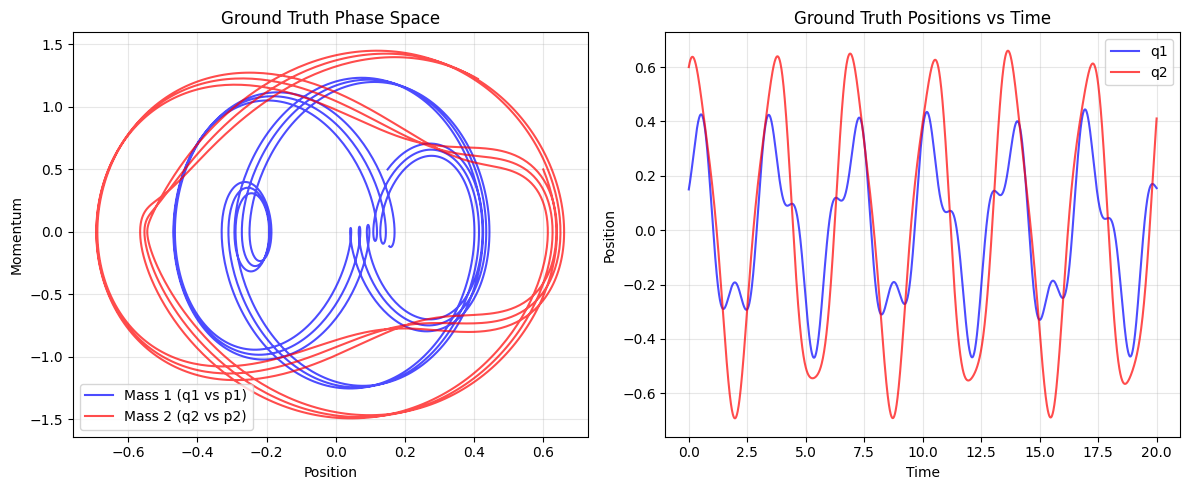


--- Step 3: Instantiating the Standard Neural ODE Model (4D) ---
SIMD Batch Size: 4
Standard Neural ODE model (4D) instantiated.

--- Step 4: Instantiating the Neural Hamiltonian ODE Model (4D) ---
Neural Hamiltonian ODE model instantiated with symplectic structure.

--- Step 6: Running Training ---

--- Training Standard Neural ODE (4D) for 2000 epochs ---
Standard Neural ODE Epoch [500/2000], Loss: 1.147450e-01
Standard Neural ODE Epoch [1000/2000], Loss: 1.220511e-01
Standard Neural ODE Epoch [1500/2000], Loss: 1.093574e-01
Standard Neural ODE Epoch [2000/2000], Loss: 1.259939e-01
Standard Neural ODE Training completed in 976.80 seconds.

--- Training Neural Hamiltonian ODE (4D) for 2000 epochs ---
Neural Hamiltonian ODE Epoch [500/2000], Loss: 1.146040e-01
Neural Hamiltonian ODE Epoch [1000/2000], Loss: 1.211877e-01
Neural Hamiltonian ODE Epoch [1500/2000], Loss: 1.211222e-01
Neural Hamiltonian ODE Epoch [2000/2000], Loss: 1.263203e-01
Neural Hamiltonian ODE Training completed in 

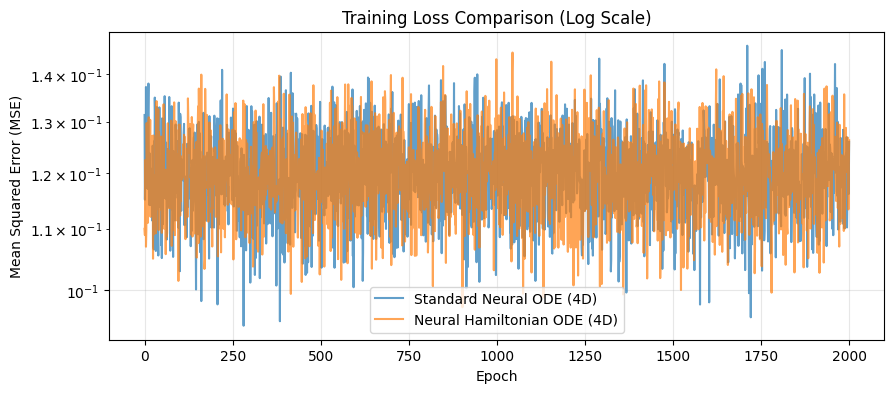


--- Step 7: Comparing Predictions ---


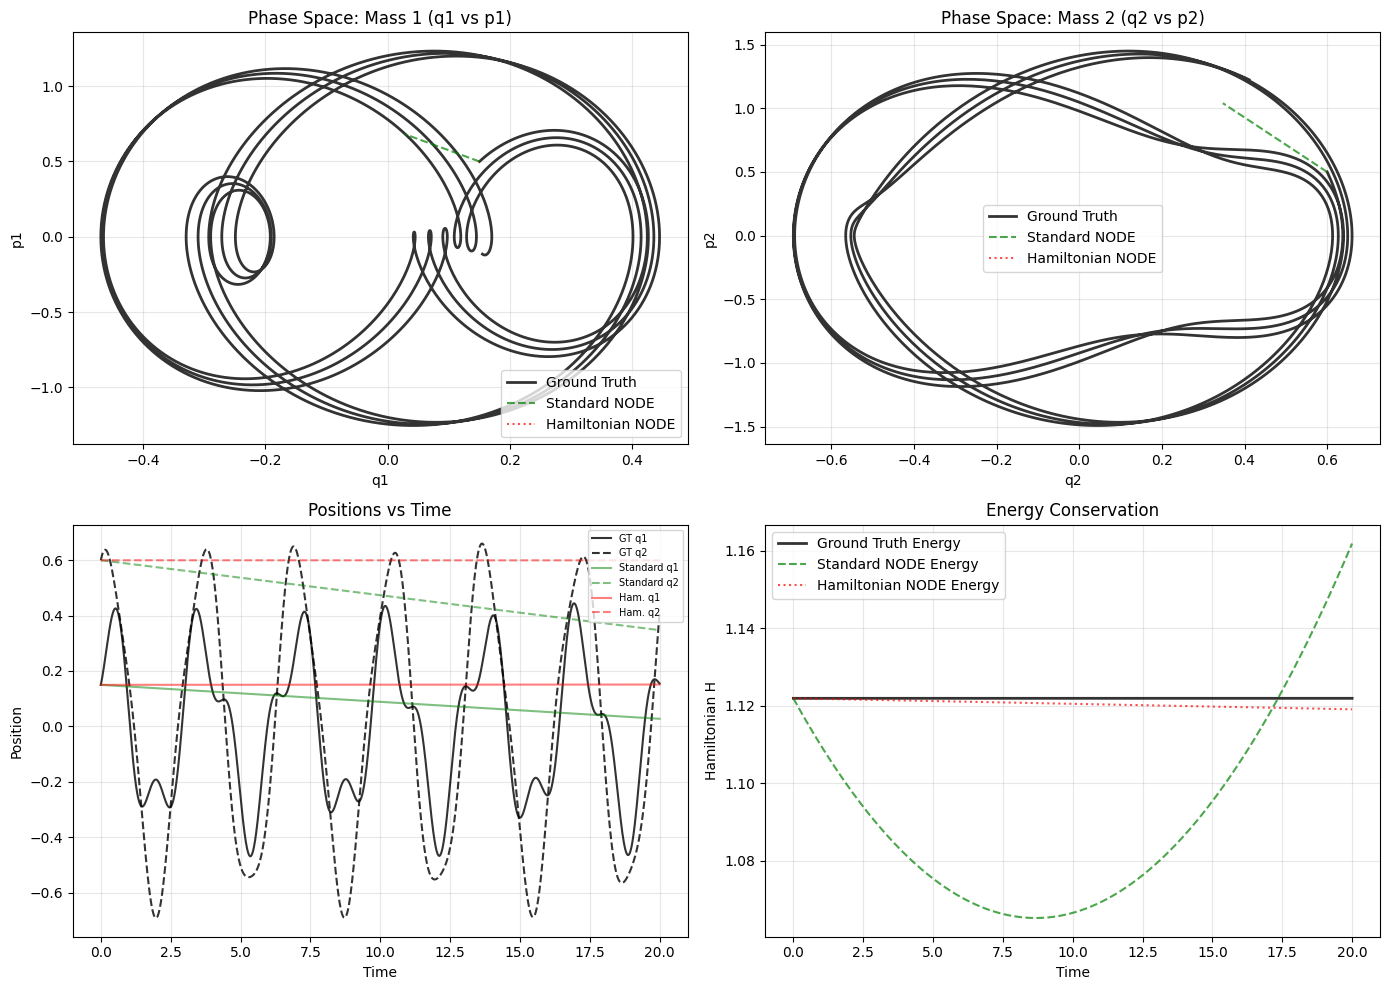


=== FINAL RESULTS ===
Standard Neural ODE Final MSE: 6.428694e-01
Neural Hamiltonian ODE Final MSE: 5.699922e-01

Energy Conservation (std dev from mean energy):
  Ground Truth: 3.967954e-16 (numerical error only)
  Standard NODE: 2.526190e-02
  Hamiltonian NODE: 8.196787e-04

Key advantages of Neural Hamiltonian ODE:
  1. Enforces symplectic structure by construction
  2. Learns a scalar Hamiltonian H(q,p) - interpretable energy
  3. Better long-term energy conservation (critical for Hamiltonian systems)
  4. Time-reversible dynamics (if symplectic integrator used)


In [27]:
# @title Neural Hamiltonian ODE - Double Mass-Spring System (Corrected)
# Based on: https://github.com/opinti/hamiltonian-neural-ode
# Ground truth: Double mass-spring system (4D Hamiltonian)

import numpy as np
import time
from itertools import batched
from copy import deepcopy
import heyoka as hy
import matplotlib.pyplot as plt


# --- 2. DEFINE THE GROUND TRUTH DYNAMICS (Double Mass-Spring) ---
print("\n--- Step 2: Defining Ground Truth Dynamics (Double Mass-Spring) ---")

# Physical parameters (from opinti notebook: k1=10, k2=7.5)
k1 = 10.0
k2 = 7.5
m1 = 1.0  # unit masses
m2 = 1.0

# Symbolic variables for the Hamiltonian state: [q1, q2, p1, p2]
q1, q2, p1, p2 = hy.make_vars("q1", "q2", "p1", "p2")

# True Hamiltonian: H = T + V
# T = p1^2/(2*m1) + p2^2/(2*m2)
# V = 0.5*k1*q1^2 + 0.5*k2*(q2 - q1)^2
H_true = (p1**2 / (2*m1) + p2**2 / (2*m2) +
          0.5 * k1 * q1**2 + 0.5 * k2 * (q2 - q1)**2)

# Hamilton's equations:
# dq1/dt = dH/dp1, dq2/dt = dH/dp2
# dp1/dt = -dH/dq1, dp2/dt = -dH/dq2
dyn_true = [
    (q1, hy.diff(H_true, p1)),   # dq1/dt = p1/m1
    (q2, hy.diff(H_true, p2)),   # dq2/dt = p2/m2
    (p1, -hy.diff(H_true, q1)),  # dp1/dt = -k1*q1 + k2*(q2-q1)
    (p2, -hy.diff(H_true, q2)),  # dp2/dt = -k2*(q2-q1)
]

print(f"True Hamiltonian: H = {H_true}")
print(f"Dynamics:")
print(f"  dq1/dt = {dyn_true[0][1]}")
print(f"  dq2/dt = {dyn_true[1][1]}")
print(f"  dp1/dt = {dyn_true[2][1]}")
print(f"  dp2/dt = {dyn_true[3][1]}")

# Parameters for generating ground truth data
data_size = 2000
t_init = 0.0
t_final = 20.0
# Initial conditions from notebook: [q1, q2, p1, p2] = [0.15, 0.6, 0.5, 0.5]
ic_true = [0.15, 0.6, 0.5, 0.5]
t_grid_true = np.linspace(t_init, t_final, data_size)

# Instantiate the Taylor integrator for the true dynamics
ta_true = hy.taylor_adaptive(
    dyn_true, ic_true, compact_mode=False, tol=1e-15
)

# Generate the ground truth trajectory
ta_true.time = t_init
ta_true.state[:] = ic_true
gt_data = ta_true.propagate_grid(t_grid_true)[5]

print(f"Ground truth data generated with {len(gt_data)} points.")

# Add noise to match the notebook (noise_level=0.015)
noise_level = 0.015
np.random.seed(42)
gt_data_noisy = gt_data + np.random.normal(0, noise_level, gt_data.shape)

# Plot the ground truth phase spaces
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(gt_data[:, 0], gt_data[:, 2], 'b-', label='Mass 1 (q1 vs p1)', alpha=0.7)
axes[0].plot(gt_data[:, 1], gt_data[:, 3], 'r-', label='Mass 2 (q2 vs p2)', alpha=0.7)
axes[0].set_title("Ground Truth Phase Space")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Momentum")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_grid_true, gt_data[:, 0], 'b-', label='q1', alpha=0.7)
axes[1].plot(t_grid_true, gt_data[:, 1], 'r-', label='q2', alpha=0.7)
axes[1].set_title("Ground Truth Positions vs Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Position")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. INSTANTIATE THE STANDARD NEURAL ODE MODEL (4D) ---
print("\n--- Step 3: Instantiating the Standard Neural ODE Model (4D) ---")

# Standard Neural ODE: learns f_theta(q1, q2, p1, p2) directly
# Inputs are the full state [q1, q2, p1, p2]
ffnn_model_standard = hy.model.ffnn(
    inputs=[q1, q2, p1, p2],
    nn_hidden=[64, 64],            # Two hidden layers
    n_out=4,                       # Output 4 values (derivatives of all state vars)
    activations=[hy.tanh, hy.tanh, lambda v: v],
)

dyn_standard_neural = [
    (q1, ffnn_model_standard[0]),
    (q2, ffnn_model_standard[1]),
    (p1, ffnn_model_standard[2]),
    (p2, ffnn_model_standard[3]),
]

# Augment with variational equations
var_dyn_standard = hy.var_ode_sys(dyn_standard_neural, args=hy.var_args.params, order=1)

precision = np.double
batch_size_simd = hy.recommended_simd_size(fp_type=precision)
print(f"SIMD Batch Size: {batch_size_simd}")

ta_train_standard = hy.taylor_adaptive_batch(
    var_dyn_standard,
    np.ones((len(dyn_standard_neural), batch_size_simd), dtype=precision),
    compact_mode=True,
    tol=precision(1e-4),
    fp_type=precision,
)

ta_infer_standard = hy.taylor_adaptive(
    var_dyn_standard,
    ic_true,
    compact_mode=True,
    tol=precision(1e-4),
    fp_type=precision,
)

ic_train_standard = np.array(ta_train_standard.state)
ic_infer_standard = np.array(ta_infer_standard.state)
print("Standard Neural ODE model (4D) instantiated.")

# --- 4. INSTANTIATE THE NEURAL HAMILTONIAN ODE MODEL (4D) ---
print("\n--- Step 4: Instantiating the Neural Hamiltonian ODE Model (4D) ---")

# Neural Hamiltonian: learn H_theta(q1, q2, p1, p2) as a scalar neural network
# Then derive dynamics via Hamilton's equations (structure-preserving)
nn_hamiltonian = hy.model.ffnn(
    inputs=[q1, q2, p1, p2],
    nn_hidden=[64, 64],
    n_out=1,                       # Scalar Hamiltonian
    activations=[hy.tanh, hy.tanh, lambda v: v],
)

H_theta = nn_hamiltonian[0]

# Hamilton's equations enforce symplectic structure:
# dq/dt = +dH/dp, dp/dt = -dH/dq
dyn_neural_hamiltonian = [
    (q1,  hy.diff(H_theta, p1)),   # dq1/dt = +dH/dp1
    (q2,  hy.diff(H_theta, p2)),   # dq2/dt = +dH/dp2
    (p1, -hy.diff(H_theta, q1)),   # dp1/dt = -dH/dq1
    (p2, -hy.diff(H_theta, q2)),   # dp2/dt = -dH/dq2
]
ham_dim = len(dyn_neural_hamiltonian)

var_dyn_ham = hy.var_ode_sys(dyn_neural_hamiltonian, args=hy.var_args.params, order=1)

ta_train_ham = hy.taylor_adaptive_batch(
    var_dyn_ham,
    np.ones((ham_dim, batch_size_simd), dtype=precision),
    compact_mode=True,
    tol=precision(1e-4),
    fp_type=precision,
)

ta_infer_ham = hy.taylor_adaptive(
    var_dyn_ham,
    ic_true,
    compact_mode=True,
    tol=precision(1e-4),
    fp_type=precision,
)

ic_train_ham = np.array(ta_train_ham.state)
ic_infer_ham = np.array(ta_infer_ham.state)
print("Neural Hamiltonian ODE model instantiated with symplectic structure.")

# --- 5. TRAINING FUNCTIONS ---

def train_standard_neural_ode(num_epochs=3000, lr=0.01):
    print(f"\n--- Training Standard Neural ODE (4D) for {num_epochs} epochs ---")

    def calculate_loss_and_grad(nn_weights, batch_ics, batch_targets, ta_batch_integrator, ic_batch, t_grid_batch):
        total_loss = 0.0
        total_grad = np.zeros_like(nn_weights)
        batch_size_ic = batch_ics.shape[0]
        batch_size_time = batch_targets.shape[0]
        dim = batch_targets.shape[-1]  # 4D state
        num_params = len(nn_weights)

        counter = 0
        for batch_chunk in batched(batch_ics, batch_size_simd):
            chunk_size = len(batch_chunk)

            ta_batch_integrator.set_time(precision(0.0))
            ta_batch_integrator.state[:, :] = deepcopy(ic_batch)
            ta_batch_integrator.state[:dim, :chunk_size] = np.array(batch_chunk).T
            ta_batch_integrator.pars[:] = np.tile(nn_weights, (batch_size_simd, 1)).T

            solution_history = ta_batch_integrator.propagate_grid(np.array(t_grid_batch, dtype=precision))[1]

            for i in range(chunk_size):
                sol_trajectory = solution_history[:, :, i]
                pred_states = sol_trajectory[:, :dim]  # (T, 4)
                targets_for_item = batch_targets[:, counter, :]  # (T, 4)

                error = pred_states - targets_for_item
                total_loss += np.sum(error**2)

                # Sensitivity extraction: variational state follows original state
                sensitivities_flat = sol_trajectory[:, dim:]  # (T, 4*num_params)
                sensitivities = sensitivities_flat.reshape(batch_size_time, dim, num_params)

                grad_contrib = 2 * np.sum(error[:, :, np.newaxis] * sensitivities, axis=(0, 1))
                total_grad += grad_contrib

                counter += 1

        total_loss /= (batch_size_ic * batch_size_time)
        total_grad /= (batch_size_ic * batch_size_time)

        return total_loss, total_grad

    def get_batch(t_grid, gt, batch_size_ic=40, batch_size_time=20):
        s_indices = np.random.choice(
            np.arange(gt.shape[0] - batch_size_time, dtype=np.int64),
            batch_size_ic,
            replace=False,
        )
        batch_ics = gt[s_indices, :]  # (M, 4)
        batch_t_grid = t_grid[:batch_size_time]  # (T,)
        batch_targets = np.stack([gt[s_indices + i] for i in range(batch_size_time)])  # (T, M, 4)
        return batch_ics, batch_t_grid, batch_targets

    num_parameters = len(ta_train_standard.pars)
    initial_weights = np.random.normal(loc=0, scale=0.01, size=(num_parameters,))
    losses = []

    start_time_training = time.time()
    for epoch in range(num_epochs):
        batch_ics, batch_times, batch_targets = get_batch(t_grid_true, gt_data_noisy, 40, 20)
        t_grid_batch = np.repeat(batch_times, batch_size_simd).reshape(-1, batch_size_simd)

        current_loss, grad = calculate_loss_and_grad(initial_weights, batch_ics, batch_targets,
                                                      ta_train_standard, ic_train_standard, t_grid_batch)
        losses.append(current_loss)
        initial_weights -= lr * grad

        if (epoch + 1) % 500 == 0:
            print(f"Standard Neural ODE Epoch [{epoch+1}/{num_epochs}], Loss: {current_loss:.6e}")

    print(f"Standard Neural ODE Training completed in {time.time() - start_time_training:.2f} seconds.")
    return initial_weights, losses

def train_neural_hamiltonian(num_epochs=3000, lr=0.01):
    print(f"\n--- Training Neural Hamiltonian ODE (4D) for {num_epochs} epochs ---")

    def calculate_loss_and_grad(nn_weights, batch_ics, batch_targets, ta_batch_integrator, ic_batch, t_grid_batch):
        total_loss = 0.0
        total_grad = np.zeros_like(nn_weights)
        batch_size_ic = batch_ics.shape[0]
        batch_size_time = batch_targets.shape[0]
        dim = batch_targets.shape[-1]  # 4D state
        num_params = len(nn_weights)

        counter = 0
        for batch_chunk in batched(batch_ics, batch_size_simd):
            chunk_size = len(batch_chunk)

            ta_batch_integrator.set_time(precision(0.0))
            ta_batch_integrator.state[:, :] = deepcopy(ic_batch)
            ta_batch_integrator.state[:dim, :chunk_size] = np.array(batch_chunk).T
            ta_batch_integrator.pars[:] = np.tile(nn_weights, (batch_size_simd, 1)).T

            solution_history = ta_batch_integrator.propagate_grid(np.array(t_grid_batch, dtype=precision))[1]

            for i in range(chunk_size):
                sol_trajectory = solution_history[:, :, i]
                pred_states = sol_trajectory[:, :dim]  # (T, 4)
                targets_for_item = batch_targets[:, counter, :]  # (T, 4)

                error = pred_states - targets_for_item
                total_loss += np.sum(error**2)

                # Sensitivity extraction
                sensitivities_flat = sol_trajectory[:, dim:]  # (T, 4*num_params)
                sensitivities = sensitivities_flat.reshape(batch_size_time, dim, num_params)

                grad_contrib = 2 * np.sum(error[:, :, np.newaxis] * sensitivities, axis=(0, 1))
                total_grad += grad_contrib

                counter += 1

        total_loss /= (batch_size_ic * batch_size_time)
        total_grad /= (batch_size_ic * batch_size_time)

        return total_loss, total_grad

    def get_batch(t_grid, gt, batch_size_ic=40, batch_size_time=20):
        s_indices = np.random.choice(
            np.arange(gt.shape[0] - batch_size_time, dtype=np.int64),
            batch_size_ic,
            replace=False,
        )
        batch_ics = gt[s_indices, :]  # (M, 4)
        batch_t_grid = t_grid[:batch_size_time]  # (T,)
        batch_targets = np.stack([gt[s_indices + i] for i in range(batch_size_time)])  # (T, M, 4)
        return batch_ics, batch_t_grid, batch_targets

    num_parameters = len(ta_train_ham.pars)
    initial_weights = np.random.normal(loc=0, scale=0.01, size=(num_parameters,))
    losses = []

    start_time_training = time.time()
    for epoch in range(num_epochs):
        batch_ics, batch_times, batch_targets = get_batch(t_grid_true, gt_data_noisy, 40, 20)
        t_grid_batch = np.repeat(batch_times, batch_size_simd).reshape(-1, batch_size_simd)

        current_loss, grad = calculate_loss_and_grad(initial_weights, batch_ics, batch_targets,
                                                      ta_train_ham, ic_train_ham, t_grid_batch)
        losses.append(current_loss)
        initial_weights -= lr * grad

        if (epoch + 1) % 500 == 0:
            print(f"Neural Hamiltonian ODE Epoch [{epoch+1}/{num_epochs}], Loss: {current_loss:.6e}")

    print(f"Neural Hamiltonian ODE Training completed in {time.time() - start_time_training:.2f} seconds.")
    return initial_weights, losses


# --- 6. RUN TRAINING ---
print("\n--- Step 6: Running Training ---")
standard_weights, standard_losses = train_standard_neural_ode(num_epochs=2000)
neural_ham_weights, neural_ham_losses = train_neural_hamiltonian(num_epochs=2000)

# Plot training losses
plt.figure(figsize=(10, 4))
plt.semilogy(standard_losses, label='Standard Neural ODE (4D)', alpha=0.7)
plt.semilogy(neural_ham_losses, label='Neural Hamiltonian ODE (4D)', alpha=0.7)
plt.title("Training Loss Comparison (Log Scale)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 7. COMPARISON PREDICTIONS ---
print("\n--- Step 7: Comparing Predictions ---")

# Standard Neural ODE Prediction (4D)
ta_infer_standard.time = t_init
ta_infer_standard.state[:] = list(ic_infer_standard)
ta_infer_standard.state[:4] = ic_true
ta_infer_standard.pars[:] = np.array(standard_weights, dtype=precision)
standard_pred_full = ta_infer_standard.propagate_grid(np.array(t_grid_true, dtype=precision))[5]
standard_pred = standard_pred_full[:, :4]

# Neural Hamiltonian ODE Prediction (4D)
ta_infer_ham.time = t_init
ta_infer_ham.state[:] = list(ic_infer_ham)
ta_infer_ham.state[:4] = ic_true
ta_infer_ham.pars[:] = np.array(neural_ham_weights, dtype=precision)
neural_ham_pred_full = ta_infer_ham.propagate_grid(np.array(t_grid_true, dtype=precision))[5]
neural_ham_pred = neural_ham_pred_full[:, :4]

# Compute energies along trajectories
def compute_energy_hamiltonian(traj, k1, k2, m1, m2):
    """Compute true Hamiltonian energy for double mass-spring."""
    q1, q2, p1, p2 = traj[:, 0], traj[:, 1], traj[:, 2], traj[:, 3]
    T = 0.5 * (p1**2 / m1 + p2**2 / m2)
    V = 0.5 * k1 * q1**2 + 0.5 * k2 * (q2 - q1)**2
    return T + V

E_gt = compute_energy_hamiltonian(gt_data, k1, k2, m1, m2)
E_standard = compute_energy_hamiltonian(standard_pred, k1, k2, m1, m2)
E_hamiltonian = compute_energy_hamiltonian(neural_ham_pred, k1, k2, m1, m2)

# Plotting Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase space mass 1
axes[0, 0].plot(gt_data[:, 0], gt_data[:, 2], 'k-', label='Ground Truth', linewidth=2, alpha=0.8)
axes[0, 0].plot(standard_pred[:, 0], standard_pred[:, 2], 'g--', label='Standard NODE', linewidth=1.5, alpha=0.7)
axes[0, 0].plot(neural_ham_pred[:, 0], neural_ham_pred[:, 2], 'r:', label='Hamiltonian NODE', linewidth=1.5, alpha=0.7)
axes[0, 0].set_title("Phase Space: Mass 1 (q1 vs p1)")
axes[0, 0].set_xlabel("q1")
axes[0, 0].set_ylabel("p1")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase space mass 2
axes[0, 1].plot(gt_data[:, 1], gt_data[:, 3], 'k-', label='Ground Truth', linewidth=2, alpha=0.8)
axes[0, 1].plot(standard_pred[:, 1], standard_pred[:, 3], 'g--', label='Standard NODE', linewidth=1.5, alpha=0.7)
axes[0, 1].plot(neural_ham_pred[:, 1], neural_ham_pred[:, 3], 'r:', label='Hamiltonian NODE', linewidth=1.5, alpha=0.7)
axes[0, 1].set_title("Phase Space: Mass 2 (q2 vs p2)")
axes[0, 1].set_xlabel("q2")
axes[0, 1].set_ylabel("p2")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Positions vs time
axes[1, 0].plot(t_grid_true, gt_data[:, 0], 'k-', label='GT q1', alpha=0.8)
axes[1, 0].plot(t_grid_true, gt_data[:, 1], 'k--', label='GT q2', alpha=0.8)
axes[1, 0].plot(t_grid_true, standard_pred[:, 0], 'g-', label='Standard q1', alpha=0.5)
axes[1, 0].plot(t_grid_true, standard_pred[:, 1], 'g--', label='Standard q2', alpha=0.5)
axes[1, 0].plot(t_grid_true, neural_ham_pred[:, 0], 'r-', label='Ham. q1', alpha=0.5)
axes[1, 0].plot(t_grid_true, neural_ham_pred[:, 1], 'r--', label='Ham. q2', alpha=0.5)
axes[1, 0].set_title("Positions vs Time")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Position")
axes[1, 0].legend(loc='upper right', fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

# Energy conservation
axes[1, 1].plot(t_grid_true, E_gt, 'k-', label='Ground Truth Energy', linewidth=2, alpha=0.8)
axes[1, 1].plot(t_grid_true, E_standard, 'g--', label='Standard NODE Energy', linewidth=1.5, alpha=0.7)
axes[1, 1].plot(t_grid_true, E_hamiltonian, 'r:', label='Hamiltonian NODE Energy', linewidth=1.5, alpha=0.7)
axes[1, 1].set_title("Energy Conservation")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Hamiltonian H")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute and display final errors
standard_mse = np.mean((standard_pred - gt_data)**2)
hamiltonian_mse = np.mean((neural_ham_pred - gt_data)**2)

# Energy drift metrics
E_gt_mean = np.mean(E_gt)
standard_energy_drift = np.std(E_standard - E_gt_mean)
hamiltonian_energy_drift = np.std(E_hamiltonian - E_gt_mean)

print("\n=== FINAL RESULTS ===")
print(f"Standard Neural ODE Final MSE: {standard_mse:.6e}")
print(f"Neural Hamiltonian ODE Final MSE: {hamiltonian_mse:.6e}")
print(f"\nEnergy Conservation (std dev from mean energy):")
print(f"  Ground Truth: {np.std(E_gt - E_gt_mean):.6e} (numerical error only)")
print(f"  Standard NODE: {standard_energy_drift:.6e}")
print(f"  Hamiltonian NODE: {hamiltonian_energy_drift:.6e}")
print(f"\nKey advantages of Neural Hamiltonian ODE:")
print(f"  1. Enforces symplectic structure by construction")
print(f"  2. Learns a scalar Hamiltonian H(q,p) - interpretable energy")
print(f"  3. Better long-term energy conservation (critical for Hamiltonian systems)")
print(f"  4. Time-reversible dynamics (if symplectic integrator used)")